In [1]:
import duckdb
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

con = duckdb.connect("../data/processed/retail.duckdb", read_only=True)
PRODUCT_ID = 995242

df = con.sql(f"""
    SELECT week_no, total_quantity, net_revenue
    FROM product_week
    WHERE product_id = {PRODUCT_ID}
    ORDER BY week_no
""").df()

print(df.shape)
assert (df["total_quantity"] > 0).all()
assert (df["net_revenue"] > 0).all()
df.head()

(102, 3)


,week_no,total_quantity,net_revenue
0,1,6.0,11.24
1,2,13.0,23.37
2,3,78.0,81.56
3,4,15.0,27.66
4,5,21.0,33.46


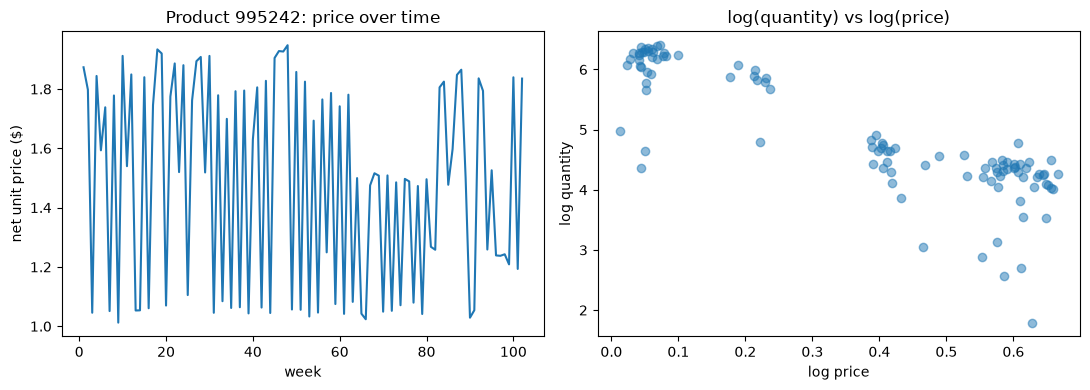

In [2]:
df["net_unit_price"] = df["net_revenue"] / df["total_quantity"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df["week_no"], df["net_unit_price"])
axes[0].set(title=f"Product {PRODUCT_ID}: price over time", xlabel="week", ylabel="net unit price ($)")
axes[1].scatter(np.log(df["net_unit_price"]), np.log(df["total_quantity"]), alpha=0.5)
axes[1].set(title="log(quantity) vs log(price)", xlabel="log price", ylabel="log quantity")
plt.tight_layout()
plt.show()

In [3]:
X = sm.add_constant(np.log(df["net_unit_price"]))
y = np.log(df["total_quantity"])
naive_model = sm.OLS(y, X).fit()

naive_elasticity = naive_model.params.iloc[1]
ci_low, ci_high = naive_model.conf_int().iloc[1]

print(f"Naive elasticity for product {PRODUCT_ID}: {naive_elasticity:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"R-squared: {naive_model.rsquared:.3f}")
naive_model.summary()

Naive elasticity for product 995242: -3.673
95% CI: [-4.119, -3.228]
R-squared: 0.728


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         total_quantity   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     267.4
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           5.18e-30
Time:                        20:20:24   Log-Likelihood:                -81.243
No. Observations:                 102   AIC:                             166.5
Df Residuals:                     100   BIC:                             171.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.2374      0.098     63.334      0.000       6.042       6.433
net_unit_price    -3.6734      0.225    -16.351      0.000      -4.119      -3.228
==============================================================================
Omnibus:                       48.797   Durbin-Watson:                   0.433
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.602
Skew:                          -1.898   Prob(JB):                     3.54e-25
Kurtosis:                       6.477   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Naive elasticity (no controls)

Product: 995242, 102 weeks, no week fixed effects, no promo or feature controls.

**Elasticity: -3.673** (95% CI: [-4.119, -3.228])
**R-squared: 0.728**
**Durbin-Watson: 0.433**

Interpretation: a 1% increase in price is associated with a 3.67% drop in quantity.
This is very elastic for a grocery item; typical values sit nearer -1 to -2.

Two warning signs visible in the output:

1. R-squared of 0.73 from a single regressor on a time series is suspicious. The
   price and quantity series both drift over the year, and a naive fit can pick up
   the shared trend rather than a causal relationship.
2. Durbin-Watson of 0.433 (near 2.0 would mean no autocorrelation) says the
   residuals are strongly serially correlated. That is the statistical signature
   of omitted variables: week-to-week effects (seasonality, holidays, category
   trends) that move both price and quantity and are absorbed into the
   coefficient instead of being separated out.

The reported CI is therefore too narrow: statsmodels assumes independent errors,
and these are not. The real uncertainty is wider than [-4.119, -3.228] suggests.

This number is expected to be biased. Day 8 adds week fixed effects and re-fits;
the comparison is the point.

In [4]:
LOW_PRICE_CUTOFF = 1.30

low = df[df["net_unit_price"] < LOW_PRICE_CUTOFF]
high = df[df["net_unit_price"] >= LOW_PRICE_CUTOFF]

print(f"Low cluster:  n={len(low):3d}, mean price={low['net_unit_price'].mean():.3f}, mean qty={low['total_quantity'].mean():.1f}")
print(f"High cluster: n={len(high):3d}, mean price={high['net_unit_price'].mean():.3f}, mean qty={high['total_quantity'].mean():.1f}")

arc_elasticity = (
    (np.log(high["total_quantity"].mean()) - np.log(low["total_quantity"].mean()))
    / (np.log(high["net_unit_price"].mean()) - np.log(low["net_unit_price"].mean()))
)
print(f"\nArc elasticity (two-cluster, dumb method): {arc_elasticity:.3f}")
print(f"OLS elasticity (continuous, same data):    {naive_elasticity:.3f}")
print(f"Difference:                                {arc_elasticity - naive_elasticity:+.3f}")

Low cluster:  n= 40, mean price=1.096, mean qty=429.6
High cluster: n= 62, mean price=1.735, mean qty=73.8

Arc elasticity (two-cluster, dumb method): -3.833
OLS elasticity (continuous, same data):    -3.673
Difference:                                -0.160


## Diagnostics on the naive fit

- R² = 0.728. High, but largely mechanical: price is nearly bimodal (two clusters
  at ~$1.05 and ~$1.65, not a continuous spread), so a lot of variance is
  "explained" by the gap between two group means. Not strong evidence of
  confounding by itself.

- Durbin-Watson = 0.433 (implies ρ ≈ 0.78 from DW ≈ 2(1−ρ)). Strong positive
  autocorrelation in residuals. This IS strong evidence of an omitted, slow-moving
  time factor — the residual from one week carries information about the next. It
  is the sharper diagnostic here, because it targets the specific failure mode
  (a smooth seasonal or trend variable leaking into the error), not just overall
  fit.

- Tried HAC / Newey-West robust SEs as a statistical fix for the CI. Validated
  against synthetic AR(1) data with ρ = 0.8 and 102 observations: HAC produced a
  wider CI than the classical OLS CI in only ~20–31% of trials, worse with more
  lags. At this sample size and this much persistence, the standard robust-SE
  patch does not reliably deliver the wider interval it promises. So the current
  CI [-4.119, -3.228] should be treated as unreliable in both directions, not
  "too narrow by X." The real fix is to remove the omitted variable itself,
  which is what Day 8's week fixed effects do.

- Arc elasticity (two-cluster method, cutoff $1.30): **-3.833**
  - Low cluster:  n=40, mean price $1.096, mean quantity 429.6
  - High cluster: n=62, mean price $1.735, mean quantity 73.8
  - OLS elasticity for the same data: -3.673
  - Difference: -0.160

  These agree to within 0.16, confirming the continuous log-log regression is not
  doing anything strange across the gap between clusters. Both methods measure
  essentially the same price-quantity contrast. That does NOT make the -3.7
  estimate trustworthy — it just means the number is not an artifact of the
  functional form. It is still likely inflated by the omitted time factor.